In [11]:
import numpy as np
import pandas as pd
from io import StringIO

def compute_individual_weights(df, population_proportions):
    """Computes individual weights using a weighted sum approach and calculates an adjustment index."""
    
    # Compute the sum of occurrences for each category in the sample
    category_totals = df.sum(axis=0)  # Sum across individuals
    
    # Compute weights for each individual
    weights = df.apply(lambda row: sum(row[col] * (population_proportions[col] / category_totals[col]) 
                                       for col in df.columns if category_totals[col] > 0), axis=1)

    # Normalize weights to keep total sum of weights = number of individuals
    weights *= len(df) / weights.sum()

    # Compute the adjustment index
    adjustment_index = 1 - np.mean(np.abs(weights - 1))

    return dict(zip(df.index, weights)), adjustment_index

# Example data
csv_data = """
individual,A,B,C,D,E
a,1,0,1,0,1
b,0,1,0,1,0
c,1,0,1,0,0
d,0,1,0,1,0
"""

df = pd.read_csv(StringIO(csv_data), index_col=0)

population_proportions = {'A': 0.0, 'B': 1, 'C': 0.5, 'D': .5, 'E': 1}

weights, adjustment_index = compute_individual_weights(df, population_proportions)

print("Weights:", weights)
print("Adjustment Index:", adjustment_index)


Weights: {'a': 1.6666666666666665, 'b': 1.0, 'c': 0.3333333333333333, 'd': 1.0}
Adjustment Index: 0.6666666666666667


# Aplicação

In [12]:
df_parls_raw = pd.read_csv(r'../../data/df_parl_detalhes.csv', index_col=0)
df_parls_per_legislatura = pd.read_csv(r'../../data/df_parlamentares_por_legislatura.csv', index_col=0)
df_for_ird = pd.read_csv(r'../../outputs/df_for_ird.csv', index_col=0)

In [21]:
df_for_ird

,idLegislatura,F,M,branca,n_branca,parda,preta,amarela,indigena
id,,,,,,,,,
73909,52,0,1,0,0,0,0,0,0
73984,52,0,1,0,0,0,0,0,0
73764,51,0,1,0,0,0,0,0,0
73886,51,0,1,0,0,0,0,0,0
74328,51,0,1,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...
160632,55,0,1,1,0,0,0,0,0
178923,55,0,1,1,0,0,0,0,0
160592,55,0,1,1,0,0,0,0,0


In [14]:
df_parls = df_parls_raw.copy()

df_parls = df_parls.join(pd.get_dummies(df_parls['sexo']))

df_parls.set_index('id', inplace=True)

In [32]:
population_proportions = {
    "F": 0.52,
    "M": 0.48,
    # "branca": 0.2,
    # "n_branca": 0.8
    "parda": .453,
    "preta": .102,
    "amarela": .004,
    "indigena": .008
}


results = []
df_index = pd.DataFrame()
for legislatura in [54,55,56,57]:
    df_parls_leg = df_for_ird[df_for_ird['idLegislatura'] == legislatura]
    weights, adjustment_index = compute_individual_weights(df_parls_leg[population_proportions.keys()], population_proportions)
    df_index = pd.concat([df_index, pd.DataFrame({
        'parl_id': weights.keys(),
        'legislatura': legislatura,
        'weights': weights.values(),
    })])

    # print("Weights:", weights)
    print("Adjustment Index:", adjustment_index)
    results.append({
        'legislatura': legislatura,
        'adjustment_index': adjustment_index,
        "%_F": df_parls_leg['F'].sum() / (df_parls_leg['F'].sum() + df_parls_leg['M'].sum()),
        "%_n_branca": df_parls_leg['n_branca'].sum() / (df_parls_leg['n_branca'].sum() + df_parls_leg['branca'].sum()),
        "%_parda": df_parls_leg['parda'].sum() / (df_parls_leg['parda'].sum() + df_parls_leg['preta'].sum() + df_parls_leg['amarela'].sum() + df_parls_leg['indigena'].sum()),
        "%_preta": df_parls_leg['preta'].sum() / (df_parls_leg['parda'].sum() + df_parls_leg['preta'].sum() + df_parls_leg['amarela'].sum() + df_parls_leg['indigena'].sum()),
        "%_amarela": df_parls_leg['amarela'].sum() / (df_parls_leg['parda'].sum() + df_parls_leg['preta'].sum() + df_parls_leg['amarela'].sum() + df_parls_leg['indigena'].sum()),
        "%_indigena": df_parls_leg['indigena'].sum() / (df_parls_leg['parda'].sum() + df_parls_leg['preta'].sum() + df_parls_leg['amarela'].sum() + df_parls_leg['indigena'].sum()),
    })

Adjustment Index: 0.028593632522393997
Adjustment Index: 0.09502601002551847
Adjustment Index: 0.18319657978335835
Adjustment Index: 0.25210031397601396


In [24]:
df_index.to_csv('../../outputs/df_equality_index.csv', index=False)


In [25]:
pd.DataFrame(results).to_csv('../../outputs/df_ird_agg_legislatura.csv', index=False)

<Axes: xlabel='legislatura'>

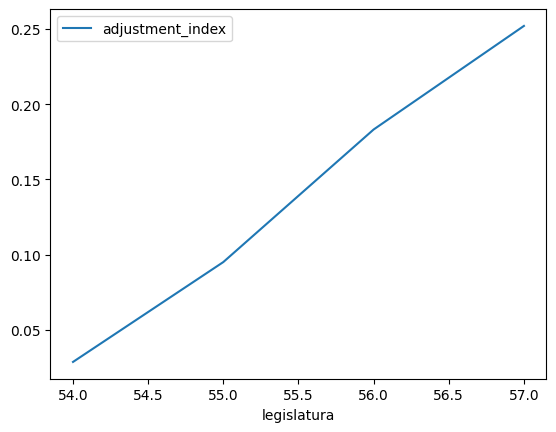

In [31]:
pd.DataFrame(results).plot(x='legislatura', y='adjustment_index', kind='line')


In [33]:
df_index

,parl_id,legislatura,weights
0,141463,54,0.338124
1,73764,54,0.338124
2,161907,54,0.338124
3,133374,54,2.327645
4,160577,54,0.338124
...,...,...,...
590,160632,57,0.374249
591,220558,57,0.374249
592,204517,57,0.374249
593,160592,57,0.374249
